# Machine Learning Capstone Project: Review 1
## Track 2: Classification Analysis (Maternal Health Risk & Cardiotocography CTG Datasets)
**Datasets:**  
1. Maternal Health Risk Dataset (`Maternal Health Risk Data Set.csv`)  
2. Cardiotocography Dataset (`CTG.xls` Sheet: `Raw Data`)  

---
### 📌 Team Member Breakdown & Notebook Structure
1. **Track A: Maternal Health Risk Dataset**
   * **Section 1 & 2:** Dataset Audit, Preprocessing, MAP Feature Engineering, Stratified 80:20 Train-Test Split.
   * **Section 3.1 - Person 1 Models:** K-Nearest Neighbors (KNN) Classifier.
   * **Section 3.2 - Person 2 Models:** Logistic Regression, Decision Tree Classifier, Support Vector Classifier (SVC), Naive Bayes (`GaussianNB`).
   * **Section 3.3 - Person 3 Models:** Random Forest Classifier, AdaBoost Classifier, XGBoost Classifier (`XGBClassifier`).
   * **Section 3.4:** Track A Consolidated Comparative Table (8 Models).
2. **Track B: Cardiotocography (CTG) Fetal Health Dataset**
   * **Section 4.1:** Dataset Audit, Preprocessing (2,126 Fetal Heart Rate recordings).
   * **Section 4.2 - Person 3 CTG Model:** Random Forest & XGBoost Multi-Class Classifiers on CTG (`Normal` vs `Suspect` vs `Pathological`).
   * **Section 4.3:** Confusion Matrix Heatmap & Classification Metrics.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Classification Algorithms
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 6)
RANDOM_STATE = 42


## 📊 1. Track A: Maternal Health Risk Dataset Audit & EDA

In [2]:
df_clf = pd.read_csv('../data/Maternal Health Risk Data Set.csv')

print("="*60)
print(f"Track A Dataset Shape: {df_clf.shape[0]} rows, {df_clf.shape[1]} columns")
print("="*60)
display(df_clf.head())

print("Target Class Distribution ('RiskLevel'):")
display(df_clf['RiskLevel'].value_counts())


Track A Dataset Shape: 1014 rows, 7 columns


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


Target Class Distribution ('RiskLevel'):


RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64

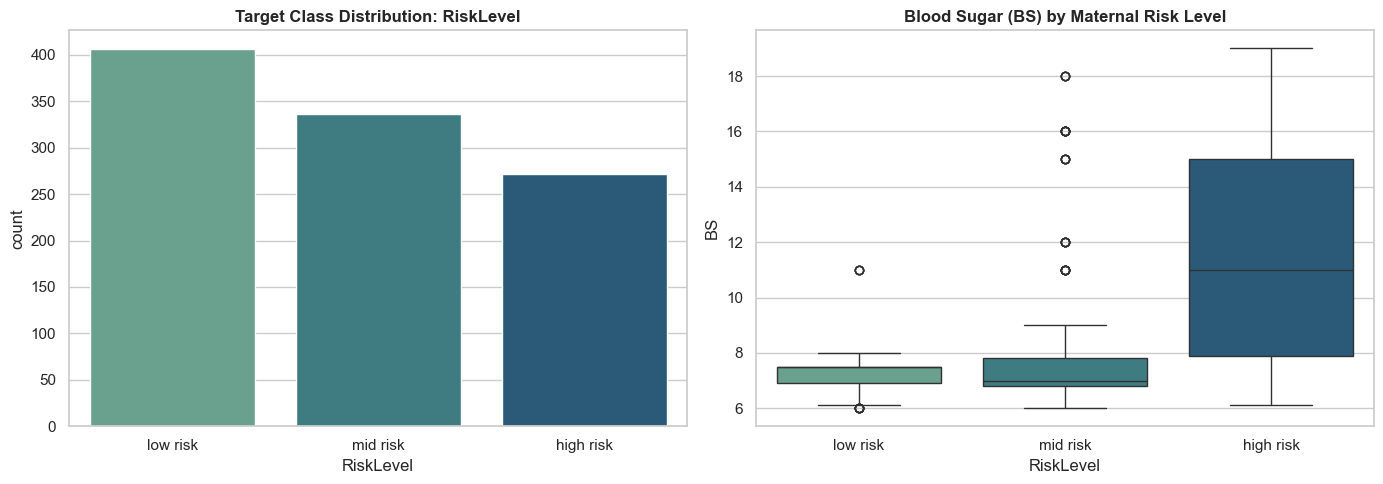

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df_clf, x='RiskLevel', order=['low risk', 'mid risk', 'high risk'], ax=axes[0], palette='crest')
axes[0].set_title('Target Class Distribution: RiskLevel', fontsize=12, fontweight='bold')

sns.boxplot(data=df_clf, x='RiskLevel', y='BS', order=['low risk', 'mid risk', 'high risk'], ax=axes[1], palette='crest')
axes[1].set_title('Blood Sugar (BS) by Maternal Risk Level', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


## ⚙️ 2. Preprocessing & Feature Engineering

In [4]:
label_enc = LabelEncoder()
df_clf['RiskLevel_Code'] = label_enc.fit_transform(df_clf['RiskLevel'])

# Feature Engineering: Mean Arterial Pressure (MAP)
df_clf['MAP'] = (df_clf['SystolicBP'] + 2 * df_clf['DiastolicBP']) / 3.0

features_c = ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate', 'MAP']
X_c = df_clf[features_c]
y_c = df_clf['RiskLevel_Code']

# Stratified Train-Test Split (80:20)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_c, y_c, test_size=0.2, random_state=RANDOM_STATE, stratify=y_c
)

# Standard Scaling fitted strictly on training data
scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

print(f"Stratified Training shape: {X_train_c.shape} | Test shape: {X_test_c.shape}")


Stratified Training shape: (811, 7) | Test shape: (203, 7)


## 👤 3. Track A Model Implementations

### 3.1 Person 1 Model: K-Nearest Neighbors (KNN) Classifier

In [5]:
best_score_knn = 0
best_params_knn = {}

for p in [1, 2]:
    for k in range(1, 15, 2):
        knn_c = KNeighborsClassifier(n_neighbors=k, p=p, weights='distance')
        score = cross_val_score(knn_c, X_train_c_scaled, y_train_c, cv=5, scoring='f1_weighted').mean()
        if score > best_score_knn:
            best_score_knn = score
            best_params_knn = {'n_neighbors': k, 'p': p}

best_knn_clf = KNeighborsClassifier(n_neighbors=best_params_knn['n_neighbors'], p=best_params_knn['p'], weights='distance')
best_knn_clf.fit(X_train_c_scaled, y_train_c)
y_pred_knn_c = best_knn_clf.predict(X_test_c_scaled)

acc_knn = accuracy_score(y_test_c, y_pred_knn_c)
prec_knn = precision_score(y_test_c, y_pred_knn_c, average='weighted')
rec_knn = recall_score(y_test_c, y_pred_knn_c, average='weighted')
f1_knn = f1_score(y_test_c, y_pred_knn_c, average='weighted')

print(f"KNN Classifier (Params={best_params_knn}): Accuracy = {acc_knn:.4f} | F1 = {f1_knn:.4f}")


KNN Classifier (Params={'n_neighbors': 3, 'p': 1}): Accuracy = 0.8079 | F1 = 0.8074


### 3.2 Person 2 Models (Linear, Tree, Kernel & Naive Bayes)

#### 3.2.1 Logistic Regression (Multi-class)

In [6]:
log_reg = LogisticRegression(max_iter=500, random_state=RANDOM_STATE)
log_reg.fit(X_train_c_scaled, y_train_c)
y_pred_log = log_reg.predict(X_test_c_scaled)

acc_log = accuracy_score(y_test_c, y_pred_log)
prec_log = precision_score(y_test_c, y_pred_log, average='weighted')
rec_log = recall_score(y_test_c, y_pred_log, average='weighted')
f1_log = f1_score(y_test_c, y_pred_log, average='weighted')

print(f"Logistic Regression: Accuracy = {acc_log:.4f} | F1 = {f1_log:.4f}")


Logistic Regression: Accuracy = 0.6207 | F1 = 0.6039


#### 3.2.2 Decision Tree Classifier (`GridSearchCV`)

In [7]:
dt_c_param_grid = {'max_depth': [3, 5, 10, 15], 'min_samples_split': [2, 5]}
dt_c_grid = GridSearchCV(DecisionTreeClassifier(random_state=RANDOM_STATE), dt_c_param_grid, cv=5, scoring='f1_weighted')
dt_c_grid.fit(X_train_c, y_train_c)

best_dt_c = dt_c_grid.best_estimator_
y_pred_dt_c = best_dt_c.predict(X_test_c)

acc_dt_c = accuracy_score(y_test_c, y_pred_dt_c)
prec_dt_c = precision_score(y_test_c, y_pred_dt_c, average='weighted')
rec_dt_c = recall_score(y_test_c, y_pred_dt_c, average='weighted')
f1_dt_c = f1_score(y_test_c, y_pred_dt_c, average='weighted')

print(f"Decision Tree Classifier: Best Params = {dt_c_grid.best_params_} | Accuracy = {acc_dt_c:.4f} | F1 = {f1_dt_c:.4f}")


Decision Tree Classifier: Best Params = {'max_depth': 15, 'min_samples_split': 2} | Accuracy = 0.8424 | F1 = 0.8439


#### 3.2.3 Support Vector Classifier (SVC RBF Kernel)

In [8]:
svc_c = SVC(kernel='rbf', C=10.0, random_state=RANDOM_STATE)
svc_c.fit(X_train_c_scaled, y_train_c)
y_pred_svc = svc_c.predict(X_test_c_scaled)

acc_svc = accuracy_score(y_test_c, y_pred_svc)
prec_svc = precision_score(y_test_c, y_pred_svc, average='weighted')
rec_svc = recall_score(y_test_c, y_pred_svc, average='weighted')
f1_svc = f1_score(y_test_c, y_pred_svc, average='weighted')

print(f"Support Vector Classifier (SVC): Accuracy = {acc_svc:.4f} | F1 = {f1_svc:.4f}")


Support Vector Classifier (SVC): Accuracy = 0.7044 | F1 = 0.6942


#### 3.2.4 Naive Bayes Classifier (`GaussianNB`)

In [9]:
nb_clf = GaussianNB()
nb_clf.fit(X_train_c_scaled, y_train_c)
y_pred_nb = nb_clf.predict(X_test_c_scaled)

acc_nb = accuracy_score(y_test_c, y_pred_nb)
prec_nb = precision_score(y_test_c, y_pred_nb, average='weighted')
rec_nb = recall_score(y_test_c, y_pred_nb, average='weighted')
f1_nb = f1_score(y_test_c, y_pred_nb, average='weighted')

print(f"Gaussian Naive Bayes: Accuracy = {acc_nb:.4f} | F1 = {f1_nb:.4f}")


Gaussian Naive Bayes: Accuracy = 0.6010 | F1 = 0.5583


### 3.3 Person 3 Models (Ensemble & Boosting Classifiers)

#### 3.3.1 Random Forest Classifier (`GridSearchCV`)

In [10]:
rf_c_param_grid = {'n_estimators': [100, 150], 'max_depth': [10, 15], 'min_samples_split': [2, 5]}
rf_c_grid = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1), rf_c_param_grid, cv=5, scoring='f1_weighted', n_jobs=1)
rf_c_grid.fit(X_train_c, y_train_c)

best_rf_c = rf_c_grid.best_estimator_
y_pred_rf_c = best_rf_c.predict(X_test_c)

acc_rf_c = accuracy_score(y_test_c, y_pred_rf_c)
prec_rf_c = precision_score(y_test_c, y_pred_rf_c, average='weighted')
rec_rf_c = recall_score(y_test_c, y_pred_rf_c, average='weighted')
f1_rf_c = f1_score(y_test_c, y_pred_rf_c, average='weighted')

print(f"Random Forest Classifier: Best Params = {rf_c_grid.best_params_} | Accuracy = {acc_rf_c:.4f} | F1 = {f1_rf_c:.4f}")


Random Forest Classifier: Best Params = {'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 150} | Accuracy = 0.8522 | F1 = 0.8537


#### 3.3.2 AdaBoost Classifier

In [11]:
ada_c = AdaBoostClassifier(n_estimators=100, learning_rate=0.1, random_state=RANDOM_STATE)
ada_c.fit(X_train_c, y_train_c)
y_pred_ada_c = ada_c.predict(X_test_c)

acc_ada_c = accuracy_score(y_test_c, y_pred_ada_c)
prec_ada_c = precision_score(y_test_c, y_pred_ada_c, average='weighted')
rec_ada_c = recall_score(y_test_c, y_pred_ada_c, average='weighted')
f1_ada_c = f1_score(y_test_c, y_pred_ada_c, average='weighted')

print(f"AdaBoost Classifier: Accuracy = {acc_ada_c:.4f} | F1 = {f1_ada_c:.4f}")


AdaBoost Classifier: Accuracy = 0.5616 | F1 = 0.5354


#### 3.3.3 XGBoost Classifier (`xgb.XGBClassifier`)

In [12]:
xgb_c = XGBClassifier(n_estimators=150, learning_rate=0.1, max_depth=5, random_state=RANDOM_STATE, n_jobs=1)
xgb_c.fit(X_train_c, y_train_c)
y_pred_xgb_c = xgb_c.predict(X_test_c)

acc_xgb_c = accuracy_score(y_test_c, y_pred_xgb_c)
prec_xgb_c = precision_score(y_test_c, y_pred_xgb_c, average='weighted')
rec_xgb_c = recall_score(y_test_c, y_pred_xgb_c, average='weighted')
f1_xgb_c = f1_score(y_test_c, y_pred_xgb_c, average='weighted')

print(f"XGBoost Classifier: Accuracy = {acc_xgb_c:.4f} | F1 = {f1_xgb_c:.4f}")


XGBoost Classifier: Accuracy = 0.8571 | F1 = 0.8590


## 📋 Track A Consolidated Summary Table (Maternal Health Risk Dataset)

In [13]:
track_a_results = [
    # Person 1
    {'Member': 'Person 1', 'Algorithm': 'K-Nearest Neighbors Classifier', 'Accuracy': acc_knn, 'Precision': prec_knn, 'Recall': rec_knn, 'Weighted F1': f1_knn},
    # Person 2
    {'Member': 'Person 2', 'Algorithm': 'Logistic Regression', 'Accuracy': acc_log, 'Precision': prec_log, 'Recall': rec_log, 'Weighted F1': f1_log},
    {'Member': 'Person 2', 'Algorithm': 'Decision Tree Classifier (Tuned)', 'Accuracy': acc_dt_c, 'Precision': prec_dt_c, 'Recall': rec_dt_c, 'Weighted F1': f1_dt_c},
    {'Member': 'Person 2', 'Algorithm': 'Support Vector Classifier (SVC)', 'Accuracy': acc_svc, 'Precision': prec_svc, 'Recall': rec_svc, 'Weighted F1': f1_svc},
    {'Member': 'Person 2', 'Algorithm': 'Gaussian Naive Bayes', 'Accuracy': acc_nb, 'Precision': prec_nb, 'Recall': rec_nb, 'Weighted F1': f1_nb},
    # Person 3
    {'Member': 'Person 3', 'Algorithm': 'Random Forest Classifier (Tuned)', 'Accuracy': acc_rf_c, 'Precision': prec_rf_c, 'Recall': rec_rf_c, 'Weighted F1': f1_rf_c},
    {'Member': 'Person 3', 'Algorithm': 'AdaBoost Classifier', 'Accuracy': acc_ada_c, 'Precision': prec_ada_c, 'Recall': rec_ada_c, 'Weighted F1': f1_ada_c},
    {'Member': 'Person 3', 'Algorithm': 'XGBoost Classifier', 'Accuracy': acc_xgb_c, 'Precision': prec_xgb_c, 'Recall': rec_xgb_c, 'Weighted F1': f1_xgb_c},
]

summary_a_df = pd.DataFrame(track_a_results).sort_values(by='Weighted F1', ascending=False).reset_index(drop=True)
display(summary_a_df.style.highlight_max(subset=['Accuracy', 'Weighted F1'], color='lightgreen').format({
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'Weighted F1': '{:.4f}'
}))


,Member,Algorithm,Accuracy,Precision,Recall,Weighted F1
0,Person 3,XGBoost Classifier,0.8571,0.8672,0.8571,0.8590
1,Person 3,Random Forest Classifier (Tuned),0.8522,0.8587,0.8522,0.8537
2,Person 2,Decision Tree Classifier (Tuned),0.8424,0.8583,0.8424,0.8439
3,Person 1,K-Nearest Neighbors Classifier,0.8079,0.8089,0.8079,0.8074
4,Person 2,Support Vector Classifier (SVC),0.7044,0.7183,0.7044,0.6942
5,Person 2,Logistic Regression,0.6207,0.6086,0.6207,0.6039
6,Person 2,Gaussian Naive Bayes,0.6010,0.5780,0.6010,0.5583
7,Person 3,AdaBoost Classifier,0.5616,0.5783,0.5616,0.5354


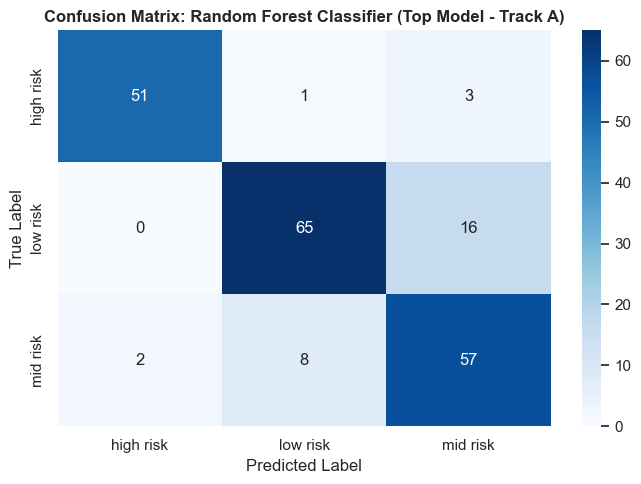

In [14]:
cm_best = confusion_matrix(y_test_c, y_pred_rf_c)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', xticklabels=label_enc.classes_, yticklabels=label_enc.classes_)
plt.title('Confusion Matrix: Random Forest Classifier (Top Model - Track A)', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()


## 🩺 4. Track B: Cardiotocography (CTG) Fetal Health Dataset Analysis (Person 3 Track)

### 4.1 Dataset Audit & Preprocessing (`data/CTG.xls`)

In [15]:
# Load CTG dataset Raw Data sheet
df_ctg = pd.read_excel('../data/CTG.xls', sheet_name='Raw Data')

# Clean and drop rows missing target 'NSP'
df_ctg = df_ctg.dropna(subset=['NSP']).copy()

# Feature columns
ctg_features = ['LBE', 'LB', 'AC', 'FM', 'UC', 'ASTV', 'MSTV', 'ALTV', 'MLTV', 'DL', 'DS', 'DP', 'DR', 'Width', 'Min', 'Max', 'Nmax', 'Nzeros', 'Mode', 'Mean', 'Median', 'Variance', 'Tendency']
X_ctg = df_ctg[ctg_features]

# Target NSP: 1.0 -> Normal (0), 2.0 -> Suspect (1), 3.0 -> Pathological (2)
y_ctg = (df_ctg['NSP'] - 1).astype(int)

print("="*60)
print(f"CTG Dataset Shape: {df_ctg.shape[0]} records, {len(ctg_features)} features")
print("Target NSP Class Distribution (0: Normal, 1: Suspect, 2: Pathological):")
print(y_ctg.value_counts())
print("="*60)

# Stratified Train-Test Split (80:20)
X_tr_ctg, X_te_ctg, y_tr_ctg, y_te_ctg = train_test_split(
    X_ctg, y_ctg, test_size=0.2, random_state=RANDOM_STATE, stratify=y_ctg
)

scaler_ctg = StandardScaler()
X_tr_ctg_s = scaler_ctg.fit_transform(X_tr_ctg)
X_te_ctg_s = scaler_ctg.transform(X_te_ctg)


CTG Dataset Shape: 2126 records, 23 features
Target NSP Class Distribution (0: Normal, 1: Suspect, 2: Pathological):
NSP
0    1655
1     295
2     176
Name: count, dtype: int64


### 4.2 Model Training on CTG Dataset (Random Forest & XGBoost Classifiers)

In [16]:
# Random Forest Classifier on CTG
rf_ctg = RandomForestClassifier(n_estimators=150, max_depth=15, random_state=RANDOM_STATE, n_jobs=1)
rf_ctg.fit(X_tr_ctg, y_tr_ctg)
p_rf_ctg = rf_ctg.predict(X_te_ctg)

acc_rf_ctg = accuracy_score(y_te_ctg, p_rf_ctg)
f1_rf_ctg = f1_score(y_te_ctg, p_rf_ctg, average='weighted')

# XGBoost Classifier on CTG
xgb_ctg = XGBClassifier(n_estimators=150, learning_rate=0.1, max_depth=5, random_state=RANDOM_STATE, n_jobs=1)
xgb_ctg.fit(X_tr_ctg, y_tr_ctg)
p_xgb_ctg = xgb_ctg.predict(X_te_ctg)

acc_xgb_ctg = accuracy_score(y_te_ctg, p_xgb_ctg)
f1_xgb_ctg = f1_score(y_te_ctg, p_xgb_ctg, average='weighted')

print("="*60)
print(f"CTG Track - Random Forest: Test Accuracy = {acc_rf_ctg:.4f} | Weighted F1 = {f1_rf_ctg:.4f}")
print(f"CTG Track - XGBoost:       Test Accuracy = {acc_xgb_ctg:.4f} | Weighted F1 = {f1_xgb_ctg:.4f}")
print("="*60)
print("Classification Report (Random Forest on CTG):")
print(classification_report(y_te_ctg, p_rf_ctg, target_names=['Normal', 'Suspect', 'Pathological']))


CTG Track - Random Forest: Test Accuracy = 0.9319 | Weighted F1 = 0.9287
CTG Track - XGBoost:       Test Accuracy = 0.9460 | Weighted F1 = 0.9446
Classification Report (Random Forest on CTG):
              precision    recall  f1-score   support

      Normal       0.95      0.99      0.97       332
     Suspect       0.85      0.68      0.75        59
Pathological       0.88      0.83      0.85        35

    accuracy                           0.93       426
   macro avg       0.89      0.83      0.86       426
weighted avg       0.93      0.93      0.93       426



### 4.3 Diagnostic Visualisations for CTG Track

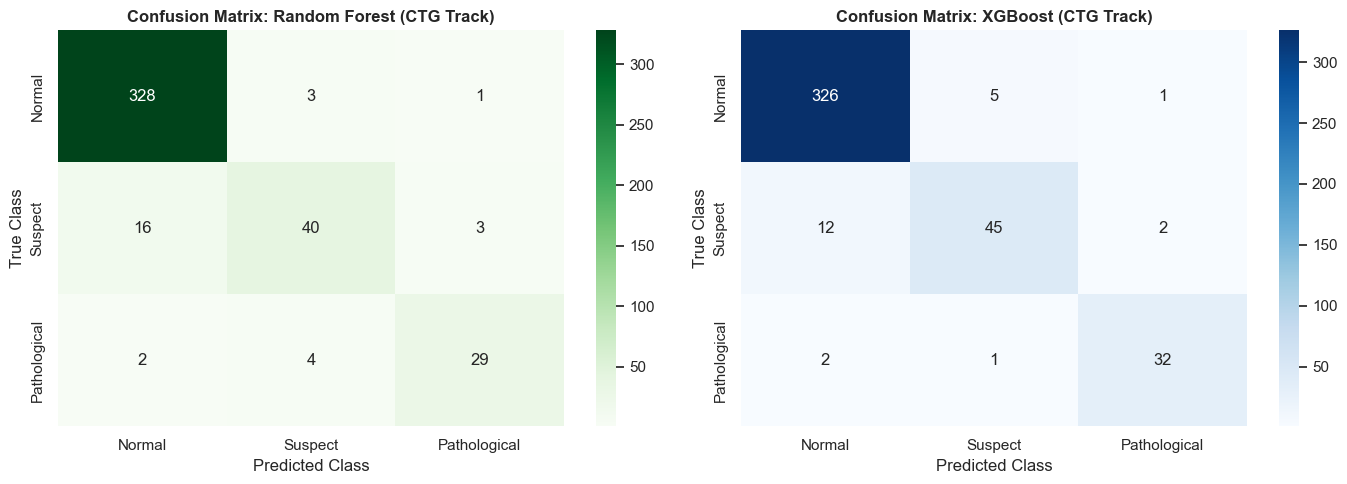

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix Random Forest CTG
cm_rf_ctg = confusion_matrix(y_te_ctg, p_rf_ctg)
sns.heatmap(cm_rf_ctg, annot=True, fmt='d', cmap='Greens', xticklabels=['Normal', 'Suspect', 'Pathological'], yticklabels=['Normal', 'Suspect', 'Pathological'], ax=axes[0])
axes[0].set_title('Confusion Matrix: Random Forest (CTG Track)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Class')
axes[0].set_ylabel('True Class')

# Confusion Matrix XGBoost CTG
cm_xgb_ctg = confusion_matrix(y_te_ctg, p_xgb_ctg)
sns.heatmap(cm_xgb_ctg, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Suspect', 'Pathological'], yticklabels=['Normal', 'Suspect', 'Pathological'], ax=axes[1])
axes[1].set_title('Confusion Matrix: XGBoost (CTG Track)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Class')
axes[1].set_ylabel('True Class')

plt.tight_layout()
plt.show()


## 📋 Track B Summary Table (Cardiotocography CTG Dataset)

In [18]:
ctg_results = [
    {'Algorithm': 'Random Forest Classifier (CTG)', 'Accuracy': acc_rf_ctg, 'Precision': precision_score(y_te_ctg, p_rf_ctg, average='weighted'), 'Recall': recall_score(y_te_ctg, p_rf_ctg, average='weighted'), 'Weighted F1': f1_rf_ctg},
    {'Algorithm': 'XGBoost Classifier (CTG)', 'Accuracy': acc_xgb_ctg, 'Precision': precision_score(y_te_ctg, p_xgb_ctg, average='weighted'), 'Recall': recall_score(y_te_ctg, p_xgb_ctg, average='weighted'), 'Weighted F1': f1_xgb_ctg}
]

summary_b_df = pd.DataFrame(ctg_results).sort_values(by='Weighted F1', ascending=False).reset_index(drop=True)
display(summary_b_df.style.highlight_max(subset=['Accuracy', 'Weighted F1'], color='lightgreen').format({
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'Weighted F1': '{:.4f}'
}))


,Algorithm,Accuracy,Precision,Recall,Weighted F1
0,XGBoost Classifier (CTG),0.9460,0.9446,0.9460,0.9446
1,Random Forest Classifier (CTG),0.9319,0.9289,0.9319,0.9287
